In [58]:
import os
import random

import numpy as np
import torch
from peft import LoraConfig, TaskType, get_peft_model
from torch import nn


def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)


class ModelForSourceCodeEmbedding(nn.Module):
    def __init__(self, model_name, normalize=True):
        super(ModelForSourceCodeEmbedding, self).__init__()
        self.model = AutoModel.from_pretrained(model_name)
        self.normalize = normalize

    def forward(self, **kwargs):
        model_output = self.model(**kwargs)
        embeddings = self.average_pool(model_output, kwargs.get("attention_mask"))
        if self.normalize:
            embeddings = torch.nn.functional.normalize(embeddings, p=2, dim=1)
        return embeddings

    def average_pool(self, model_output, attention_mask):
        token_embeddings = model_output[0]
        input_mask_expanded = attention_mask.unsqueeze(-1).expand(token_embeddings.size()).float()
        return (torch.sum(token_embeddings * input_mask_expanded, 1) /
                torch.clamp(input_mask_expanded.sum(1), min=1e-9))

    def __getattr__(self, name: str):
        try:
            return super().__getattr__(name)
        except AttributeError:
            return getattr(self.model, name)

In [59]:
from transformers import AutoModel, AutoTokenizer


model_name = "microsoft/codebert-base"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = ModelForSourceCodeEmbedding(model_name)

In [60]:
peft_config = LoraConfig(
    r=8,
    lora_alpha=16,
    bias="none",
    task_type=TaskType.FEATURE_EXTRACTION,
    target_modules=["key", "query", "value"],
)

model = get_peft_model(model, peft_config)
model.print_trainable_parameters()

trainable params: 442,368 || all params: 125,088,000 || trainable%: 0.3536454336147352


In [61]:
torch.cuda.empty_cache()

In [62]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device);

In [63]:
def get_cosing(q1_embs, q2_embs):
    return torch.sum(q1_embs * q2_embs, axis=1)

def get_loss(cosine_score, labels):
    return torch.mean(torch.square(labels * (1 - cosine_score) + torch.clamp((1 - labels) * cosine_score, min=0.0)))

def threshold(x):
    return 1 if x > 0.5 else 0

In [64]:
from imblearn.over_sampling import RandomOverSampler
import pandas as pd
from tqdm import tqdm


train_cases = ["case-01", "case-02", "case-03", "case-04", "case-05"]
test_cases = ["case-06", "case-07"]

all_cases = ["case-01", "case-02", "case-03", "case-04", "case-05", "case-06", "case-07"]


def get_data(original_file_path, non_plagiarized_files_paths, plagiarized_files_paths):
    data = []

    for non_plagiarized_file_path in non_plagiarized_files_paths:
        data.append([original_file_path, non_plagiarized_file_path, 0])

    for plagiarized_file_path in plagiarized_files_paths:
        data.append([original_file_path, plagiarized_file_path, 1])

    df = pd.DataFrame(data, columns=["original_code_file", "secondary_code_file", "label"])
    
    return df

def get_paths(case, mode):
    original_file_path = os.path.join("plagiarism_dataset", case, "original", os.listdir(
        f"plagiarism_dataset/{case}/original")[0])

    # get all other cases' files:
    non_plagiarized_files_paths_all = []
    if mode == "train":
        for every_other_case in train_cases:
            if every_other_case != case:
                non_plagiarized_files_paths = [os.path.join(dp, f) for dp, dn, filenames in os.walk(os.path.join("plagiarism_dataset", every_other_case)) for f in filenames if os.path.splitext(f)[1] == '.java']
                non_plagiarized_files_paths_all += non_plagiarized_files_paths
    else:
        for every_other_case in all_cases:
            if every_other_case != case:
                non_plagiarized_files_paths = [os.path.join(dp, f) for dp, dn, filenames in os.walk(os.path.join("plagiarism_dataset", every_other_case)) for f in filenames if os.path.splitext(f)[1] == '.java']
                non_plagiarized_files_paths_all += non_plagiarized_files_paths

    # add your own case non-plagiarised files:
    non_plagiarized_files_paths = [os.path.join(dp, f) for dp, dn, filenames in os.walk(os.path.join(
        "plagiarism_dataset", case, "non-plagiarized")) for f in filenames if os.path.splitext(f)[1] == '.java']
    non_plagiarized_files_paths_all += non_plagiarized_files_paths

    plagiarized_files_paths = [os.path.join(dp, f) for dp, dn, filenames in os.walk(os.path.join(
        "plagiarism_dataset", case, "plagiarized")) for f in filenames if os.path.splitext(f)[1] == '.java']

    return original_file_path, non_plagiarized_files_paths_all, plagiarized_files_paths

In [65]:
original_file_path, non_plagiarized_files_paths, plagiarized_files_paths = get_paths("case-01", "train")
print("Original")
print(original_file_path)
print("Non-plagiarized")
print(non_plagiarized_files_paths)
print("Plagiarized")
print(plagiarized_files_paths)

Original
plagiarism_dataset\case-01\original\T1.java
Non-plagiarized
['plagiarism_dataset\\case-02\\non-plagiarized\\01\\T02.java', 'plagiarism_dataset\\case-02\\non-plagiarized\\02\\T02.java', 'plagiarism_dataset\\case-02\\non-plagiarized\\03\\Nomor2_2451041557A22145B3701B0184109CAB013.java', 'plagiarism_dataset\\case-02\\non-plagiarized\\04\\T02.java', 'plagiarism_dataset\\case-02\\non-plagiarized\\05\\T02.java', 'plagiarism_dataset\\case-02\\non-plagiarized\\06\\T02.java', 'plagiarism_dataset\\case-02\\non-plagiarized\\07\\Main.java', 'plagiarism_dataset\\case-02\\non-plagiarized\\08\\T02.java', 'plagiarism_dataset\\case-02\\non-plagiarized\\09\\t02.java', 'plagiarism_dataset\\case-02\\non-plagiarized\\10\\Main.java', 'plagiarism_dataset\\case-02\\non-plagiarized\\11\\T02.java', 'plagiarism_dataset\\case-02\\non-plagiarized\\12\\T02.java', 'plagiarism_dataset\\case-02\\non-plagiarized\\13\\No2.java', 'plagiarism_dataset\\case-02\\non-plagiarized\\14\\Soal2.java', 'plagiarism_dataset

In [66]:
original_file_path, non_plagiarized_files_paths, plagiarized_files_paths = get_paths("case-06", "test")
print("Original")
print(original_file_path)
print("Non-plagiarized")
print(non_plagiarized_files_paths)
print("Plagiarized")
print(plagiarized_files_paths)

Original
plagiarism_dataset\case-06\original\T6.java
Non-plagiarized
['plagiarism_dataset\\case-01\\non-plagiarized\\01\\T01.java', 'plagiarism_dataset\\case-01\\non-plagiarized\\02\\T01.java', 'plagiarism_dataset\\case-01\\non-plagiarized\\03\\Nomor1_2451041557A22145B3701B0184109CAB013.java', 'plagiarism_dataset\\case-01\\non-plagiarized\\04\\T01.java', 'plagiarism_dataset\\case-01\\non-plagiarized\\05\\T01.java', 'plagiarism_dataset\\case-01\\non-plagiarized\\06\\T01.java', 'plagiarism_dataset\\case-01\\non-plagiarized\\07\\Main.java', 'plagiarism_dataset\\case-01\\non-plagiarized\\08\\T01.java', 'plagiarism_dataset\\case-01\\non-plagiarized\\09\\t01.java', 'plagiarism_dataset\\case-01\\non-plagiarized\\10\\Main.java', 'plagiarism_dataset\\case-01\\non-plagiarized\\11\\T01.java', 'plagiarism_dataset\\case-01\\non-plagiarized\\12\\T01.java', 'plagiarism_dataset\\case-01\\non-plagiarized\\13\\No1.java', 'plagiarism_dataset\\case-01\\non-plagiarized\\14\\Soal1.java', 'plagiarism_dataset

In [67]:
# train-test cycle:
EPOCHS = 30

epochs_losses_train = []
epochs_accuracies_train = []

epochs_losses_test = []
epochs_accuracies_test = []

for epoch in range(EPOCHS):
    train_total_loss = 0
    train_correct = 0
    
    test_total_loss = 0
    test_correct = 0
    
    # train:
    for case in train_cases:
        original_file_path, non_plagiarized_files_paths, plagiarized_files_paths = get_paths(case, "train")
        train_df = get_data(original_file_path, non_plagiarized_files_paths, plagiarized_files_paths)
        train_df = train_df.sample(frac=1, random_state=42).reset_index(drop=True)
        X_train, y_train = train_df[["original_code_file", "secondary_code_file"]], train_df["label"]
    
        ros = RandomOverSampler(random_state=42)
        X_train, y_train = ros.fit_resample(X_train, y_train)
        
        X_train = X_train.reset_index(drop=True)
        y_train = y_train.reset_index(drop=True)
    
        optimizer = torch.optim.Adam(model.parameters(), lr=1e-5)
        loss = nn.CrossEntropyLoss()
        
        total_loss = 0
        correct = 0
        
        model.train()
        bar = tqdm(range(len(X_train)))
        for i in range(len(X_train)):
            original_code = open(X_train["original_code_file"][i], "r").read()
            secondary_code = open(X_train["secondary_code_file"][i], "r").read()
            
            q1 = tokenizer(original_code, return_tensors="pt", max_length=512, truncation=True)
            q2 = tokenizer(secondary_code, return_tensors="pt", max_length=512, truncation=True)
            
            q1 = {k: v.to(device) for k, v in q1.items()}
            q2 = {k: v.to(device) for k, v in q2.items()}
            
            label = torch.tensor([y_train[i]])
            label = label.to(device)
            
            optimizer.zero_grad()
            q1 = model(**q1)
            q2 = model(**q2)
            loss_value = get_loss(get_cosing(q1, q2).to(device), label)
            total_loss += loss_value.item()
            loss_value.backward()
            optimizer.step()
        
            prediction = threshold(get_cosing(q1, q2).item())
            if prediction == label:
                correct += 1
            bar.update(1)
        
        train_total_loss += total_loss / len(X_train)
        train_correct += correct / len(X_train)

    # test:
    for case in test_cases:
        original_file_path, non_plagiarized_files_paths, plagiarized_files_paths = get_paths(case, "test")
        test_df = get_data(original_file_path, non_plagiarized_files_paths, plagiarized_files_paths)
        test_df = test_df.sample(frac=1, random_state=42).reset_index(drop=True)
        X_test, y_test = test_df[["original_code_file", "secondary_code_file"]], test_df["label"]
    
        total_loss = 0
        correct = 0
        
        model.eval()
        bar = tqdm(range(len(X_test)))
        for i in range(len(X_test)):
            original_code = open(X_test["original_code_file"][i], "r").read()
            secondary_code = open(X_test["secondary_code_file"][i], "r").read()
            
            q1 = tokenizer(original_code, return_tensors="pt", max_length=512, truncation=True)
            q2 = tokenizer(secondary_code, return_tensors="pt", max_length=512, truncation=True)
            
            q1 = {k: v.to(device) for k, v in q1.items()}
            q2 = {k: v.to(device) for k, v in q2.items()}
            
            label = torch.tensor([y_test[i]])
            label = label.to(device)
            
            q1 = model(**q1)
            q2 = model(**q2)
            loss_value = get_loss(get_cosing(q1, q2).to(device), label)
            total_loss += loss_value.item()
            
            prediction = threshold(get_cosing(q1, q2).item())
            if prediction == label:
                correct += 1
            bar.update(1)
        
        test_total_loss += total_loss / len(X_test)
        test_correct += correct / len(X_test)
    
    epochs_losses_train.append(train_total_loss / 5)
    print(f"Epoch: {epoch}, Loss train: {train_total_loss / 5}")
    epochs_accuracies_train.append(train_correct / 5)
    print(f"Epoch: {epoch}, Accuracy train: {train_correct / 5}")
    
    epochs_losses_test.append(test_total_loss / 2)
    print(f"Epoch: {epoch}, Loss test: {test_total_loss / 2}")
    epochs_accuracies_test.append(test_correct / 2)
    print(f"Epoch: {epoch}, Accuracy test: {test_correct / 2}")

    torch.save(model, f"models_codebert/{epoch + 1}_emb_model.pth")

100%|██████████| 584/584 [01:05<00:00,  8.87it/s]

100%|██████████| 560/560 [01:47<00:00,  5.19it/s]

100%|██████████| 558/558 [01:14<00:00,  7.46it/s]

100%|██████████| 466/466 [00:32<00:00, 14.26it/s]

Epoch: 0, Loss train: 0.26178743176022856
Epoch: 0, Accuracy train: 0.6445915105552071
Epoch: 0, Loss test: 0.6741175339877563
Epoch: 0, Accuracy test: 0.11802575107296137



100%|██████████| 466/466 [00:33<00:00, 13.98it/s]

100%|██████████| 556/556 [01:15<00:00,  7.38it/s]

100%|██████████| 556/556 [01:04<00:00,  8.57it/s]

100%|██████████| 466/466 [00:31<00:00, 14.87it/s]

100%|██████████| 466/466 [00:33<00:00, 14.06it/s]

Epoch: 1, Loss train: 0.13909815470791873
Epoch: 1, Accuracy train: 0.8006999993086774
Epoch: 1, Loss test: 0.38485184844044507
Epoch: 1, Accuracy test: 0.31759656652360513


100%|██████████| 584/584 [01:06<00:00,  8.82it/s]

100%|██████████| 560/560 [01:47<00:00,  5.19it/s]

100%|██████████| 558/558 [01:14<00:00,  7.45it/s]

100%|██████████| 466/466 [00:32<00:00, 14.28it/s]

...

Epoch: 27, Loss train: 0.013612355955943812
Epoch: 27, Accuracy train: 0.9853349390432733
Epoch: 27, Loss test: 0.2764683078008665
Epoch: 27, Accuracy test: 0.6437768240343348


100%|██████████| 584/584 [01:05<00:00,  8.88it/s]

100%|██████████| 560/560 [01:47<00:00,  5.19it/s]

100%|██████████| 558/558 [01:14<00:00,  7.49it/s]

100%|██████████| 466/466 [00:32<00:00, 14.27it/s]

Epoch: 28, Loss train: 0.013869934977548057
Epoch: 28, Accuracy train: 0.9828169534317626
Epoch: 28, Loss test: 0.25155427945004133
Epoch: 28, Accuracy test: 0.6566523605150214



100%|██████████| 466/466 [00:34<00:00, 13.47it/s]

100%|██████████| 556/556 [01:15<00:00,  7.41it/s]

100%|██████████| 556/556 [01:06<00:00,  8.42it/s]

100%|██████████| 466/466 [00:33<00:00, 13.82it/s]

100%|██████████| 466/466 [00:33<00:00, 14.25it/s]

Epoch: 29, Loss train: 0.01492456432392191
Epoch: 29, Accuracy train: 0.9821320219249132
Epoch: 29, Loss test: 0.2570182403462031
Epoch: 29, Accuracy test: 0.6491416309012876


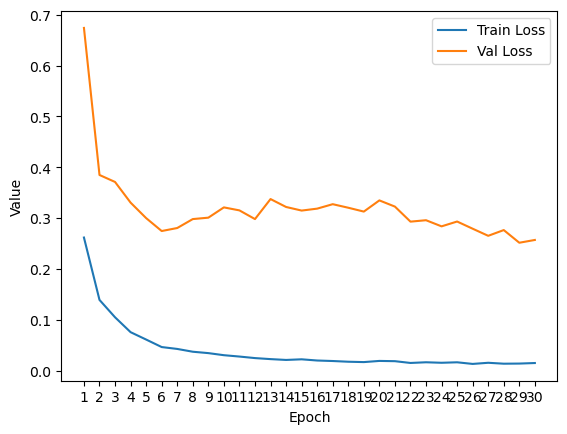

In [68]:
import matplotlib.pyplot as plt

plt.plot(range(1, EPOCHS + 1), epochs_losses_train, label="Train Loss")
plt.plot(range(1, EPOCHS + 1), epochs_losses_test, label="Val Loss")
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Value")
plt.xticks(range(1, EPOCHS + 1))

plt.show()

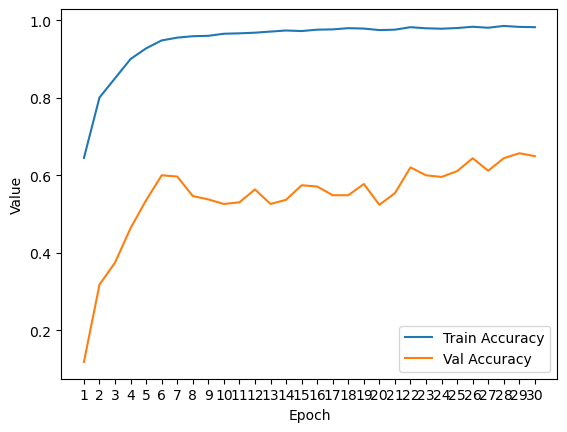

In [69]:
plt.plot(range(1, EPOCHS + 1), epochs_accuracies_train, label="Train Accuracy")
plt.plot(range(1, EPOCHS + 1), epochs_accuracies_test, label="Val Accuracy")
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Value")
plt.xticks(range(1, EPOCHS + 1))

plt.show()

In [70]:
# torch.save(model, "models_codebert/code_embedding_model.pth")

In [71]:
# model = torch.load("code_embedding_model.pth")
# model.eval()

In [72]:
epochs_losses_test, len(epochs_losses_test)

([0.6741175339877563,
  0.38485184844044507,
  0.371092786353566,
  0.33044734128778674,
  0.29999260696534796,
  0.27458601079753975,
  0.2805134214021985,
  0.2980889717807896,
  0.3008702585157187,
  0.32108555090376156,
  0.3151872253636176,
  0.29808956941300313,
  0.33746985554089715,
  0.3219075896632069,
  0.3148189682337835,
  0.318632273369836,
  0.3273840369810167,
  0.32040174867838,
  0.31282834982195606,
  0.3348310368921166,
  0.3226429855275831,
  0.29305636853827854,
  0.29584328451459696,
  0.2837843386142749,
  0.2932889194302853,
  0.2791366934686571,
  0.2651876554124304,
  0.2764683078008665,
  0.25155427945004133,
  0.2570182403462031],
 30)

In [73]:
epochs_accuracies_test, len(epochs_accuracies_test)

([0.11802575107296137,
  0.31759656652360513,
  0.3744635193133047,
  0.463519313304721,
  0.5354077253218884,
  0.599785407725322,
  0.5965665236051503,
  0.546137339055794,
  0.5375536480686696,
  0.5257510729613734,
  0.5300429184549356,
  0.5633047210300429,
  0.5257510729613735,
  0.5364806866952789,
  0.5740343347639485,
  0.5708154506437768,
  0.548283261802575,
  0.5482832618025751,
  0.5772532188841202,
  0.5236051502145922,
  0.553648068669528,
  0.6201716738197425,
  0.5997854077253219,
  0.5954935622317596,
  0.6105150214592274,
  0.6437768240343347,
  0.6115879828326181,
  0.6437768240343348,
  0.6566523605150214,
  0.6491416309012876],
 30)

In [74]:
print(f"Max accuracy: {max(epochs_accuracies_test)} at epoch {epochs_accuracies_test.index(max(epochs_accuracies_test)) + 1}")
print(f"Min loss: {min(epochs_losses_test)} at epoch {epochs_losses_test.index(min(epochs_losses_test)) + 1}")

Max accuracy: 0.6566523605150214 at epoch 29
Min loss: 0.25155427945004133 at epoch 29
